# Assignment 0: Market Sentiment vs Trading Behavior

This notebook explores how Fear-Greed sentiment relates to trader performance, position behavior, leverage proxy, and a simple predictive baseline.

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

## 1) Load Datasets

In [170]:
fear_greed_index = pd.read_csv("fear_greed_index.csv")
historical_data = pd.read_csv("historical_data.csv")

## 2) Initial Inspection

In [171]:
fear_greed_index

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [172]:
historical_data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [173]:
fear_greed_index.shape
fear_greed_index.info()
fear_greed_index.isna().sum()
fear_greed_index.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


np.int64(0)

In [174]:
historical_data.shape
historical_data.info()
historical_data.isna().sum()
historical_data.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

np.int64(0)

## 3) Date Alignment and Merge

In [175]:
historical_data['time'] = pd.to_datetime(historical_data['Timestamp'], unit='ms', errors='coerce')
historical_data['date'] = pd.to_datetime(historical_data['time']).dt.date

In [176]:
if 'Date' in fear_greed_index.columns:
    fear_greed_index['date'] = pd.to_datetime(fear_greed_index['Date'], errors='coerce').dt.date
elif 'date' in fear_greed_index.columns:
    fear_greed_index['date'] = pd.to_datetime(fear_greed_index['date'], errors='coerce').dt.date
elif 'timestamp' in fear_greed_index.columns:
    fear_greed_index['date'] = pd.to_datetime(fear_greed_index['timestamp'], unit='s', errors='coerce').dt.date
else:
    raise KeyError(f"No date source column found. Columns: {fear_greed_index.columns.tolist()}")

In [177]:
data = historical_data.merge(
    fear_greed_index[['date','classification']],
    on='date',
    how='left'
)

In [178]:
data[['date','classification']]

,date,classification
0,2024-10-27,Greed
1,2024-10-27,Greed
2,2024-10-27,Greed
3,2024-10-27,Greed
4,2024-10-27,Greed
...,...,...
211219,2025-06-15,NaN
211220,2025-06-15,NaN
211221,2025-06-15,NaN
211222,2025-06-15,NaN


In [179]:
data['classification'].isna().sum()

np.int64(26961)

In [180]:
data = data.dropna(subset=['classification'])

In [181]:
data['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

## 4) Sentiment vs Performance

In [182]:
daily_pnl = data.groupby(['Account', 'date'], as_index=False).agg(
    daily_pnl=('Closed PnL', 'sum')
)

daily_pnl.head()

,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00


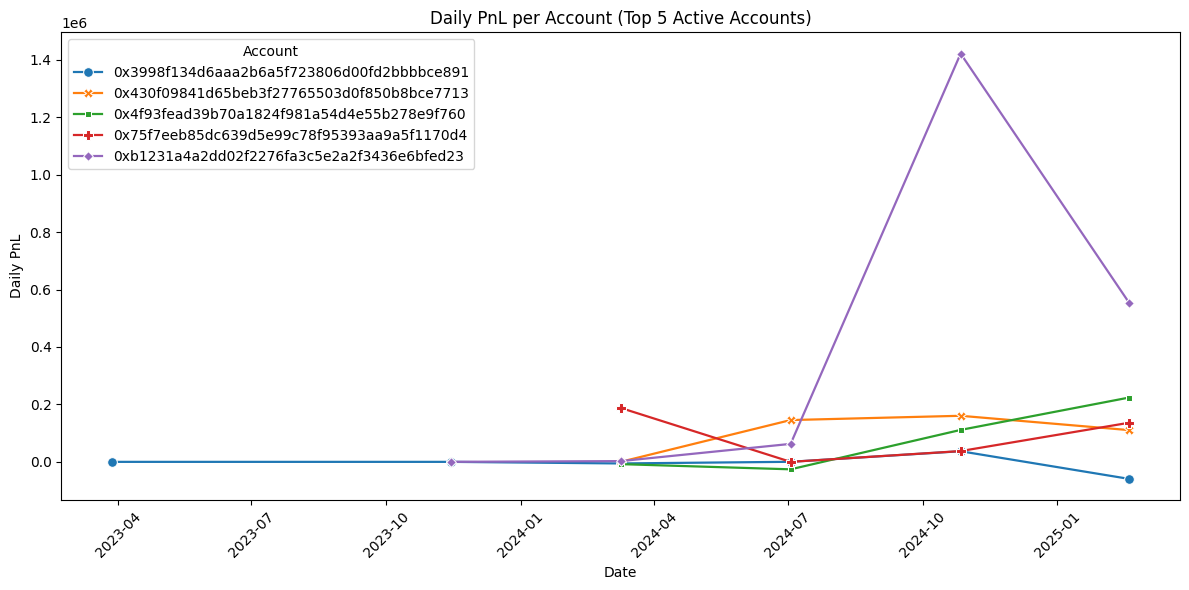

In [211]:
# Daily PnL per account (top active accounts)
import matplotlib.pyplot as plt
import seaborn as sns

top_n_accounts = 5
daily_pnl_plot = daily_pnl.copy()

# Prefer accounts with the richest time series so requested lines are visible.
account_order = (
    daily_pnl_plot.groupby('Account')
    .agg(days=('date', 'nunique'), trades=('daily_pnl', 'size'))
    .sort_values(['days', 'trades'], ascending=False)
    .head(top_n_accounts)
    .index
)

daily_pnl_plot = (
    daily_pnl_plot[daily_pnl_plot['Account'].isin(account_order)]
    .sort_values(['Account', 'date'])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_pnl_plot,
    x='date',
    y='daily_pnl',
    hue='Account',
    style='Account',
    markers=True,
    dashes=False,
    linewidth=1.6,
    markersize=7,
    estimator=None,
    units='Account',
)
plt.title(f'Daily PnL per Account (Top {top_n_accounts} Active Accounts)')
plt.xlabel('Date')
plt.ylabel('Daily PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

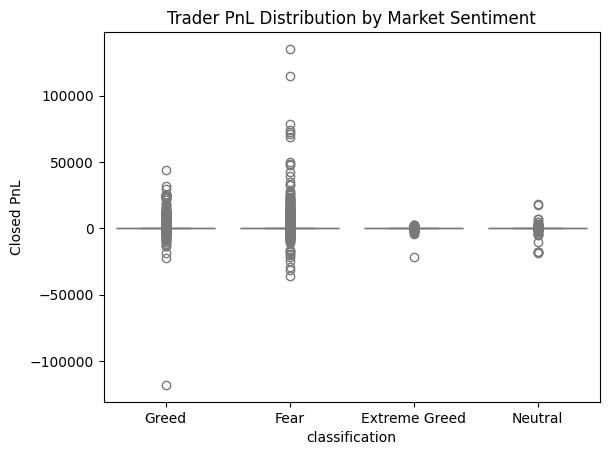

In [184]:
sns.boxplot(x='classification', y='Closed PnL', data=data, color='lightblue')
plt.title('Trader PnL Distribution by Market Sentiment')
plt.show()

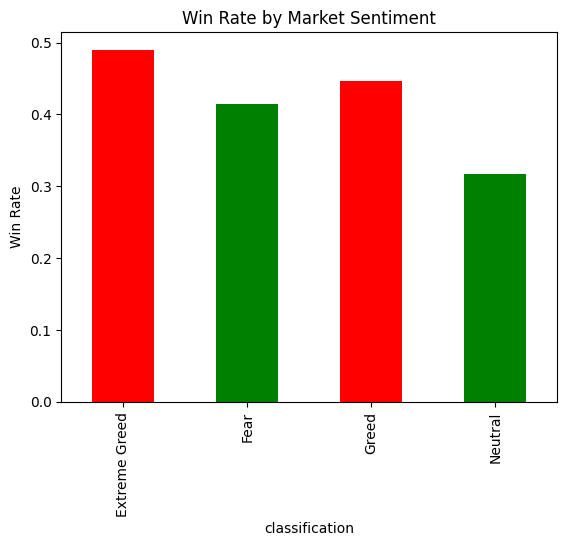

In [185]:
if 'win' not in data.columns:
    data['win'] = data['Closed PnL'] > 0

win_rate_sentiment = data.groupby('classification')['win'].mean()

win_rate_sentiment.plot(kind='bar', color=['red','green'])
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.show()

In [186]:
drawdown = data[data['Closed PnL'] < 0]

drawdown.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed    -86.703571
Fear            -150.445182
Greed           -178.268548
Neutral         -301.002712
Name: Closed PnL, dtype: float64

In [187]:
avg_trade_size = data.groupby('Account', as_index=False).agg(
    avg_trade_size=('Size USD', 'mean')
)

avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1759.743439
2,0x271b280974205ca63b716753467d5a371de622ab,10908.183944
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,509.016502
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3142.909573


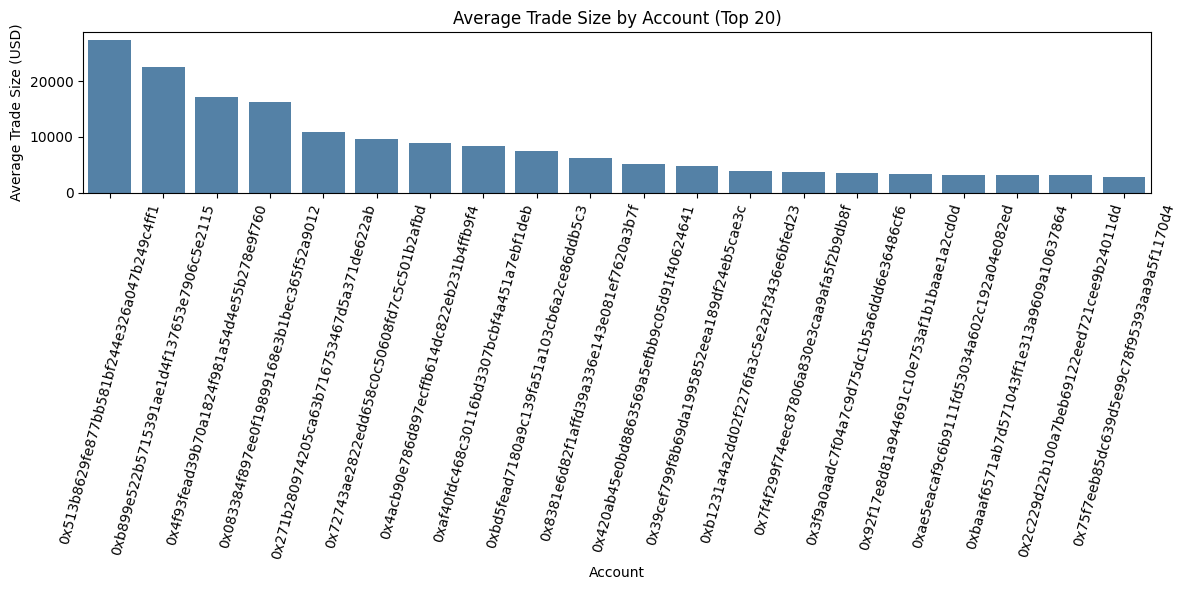

In [188]:
# Average trade size by account (top 20)
import matplotlib.pyplot as plt
import seaborn as sns

avg_trade_size_plot = avg_trade_size.sort_values('avg_trade_size', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_trade_size_plot, x='Account', y='avg_trade_size', color='steelblue')
plt.title('Average Trade Size by Account (Top 20)')
plt.xlabel('Account')
plt.ylabel('Average Trade Size (USD)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [189]:
trades_per_day = data.groupby(['date','classification']).size().reset_index(name='num_trades')


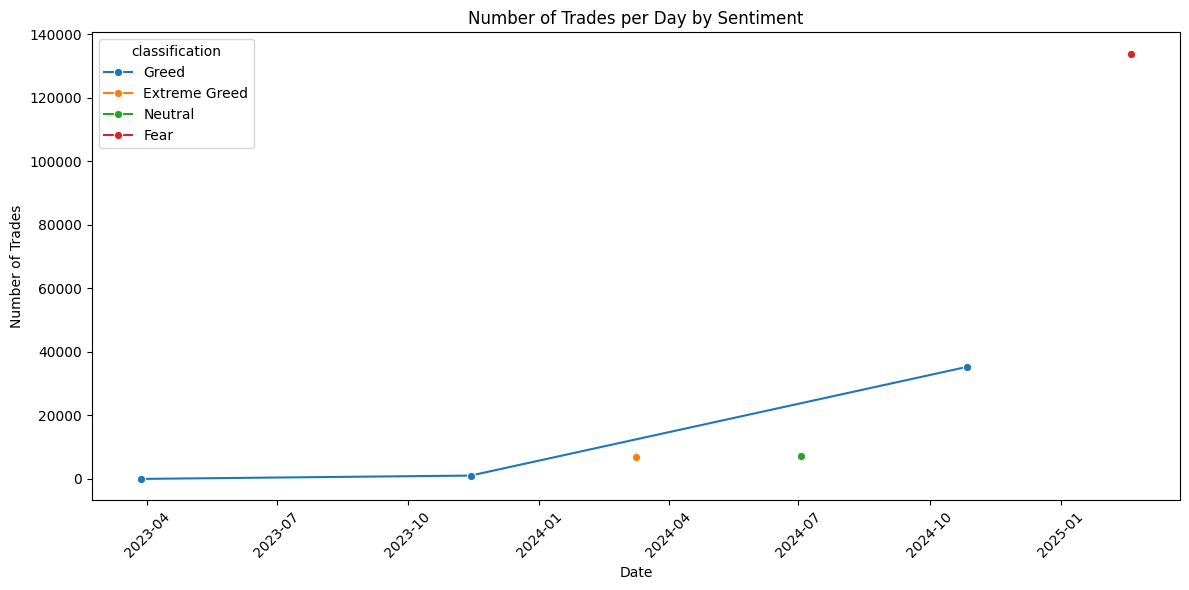

In [190]:
# Number of trades per day by sentiment
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=trades_per_day, x='date', y='num_trades', hue='classification', marker='o')
plt.title('Number of Trades per Day by Sentiment')
plt.xlabel('Date')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5) Position Behavior by Sentiment

In [191]:
data['Side'].value_counts()

Side
SELL    95885
BUY     88378
Name: count, dtype: int64

In [192]:
long_short_ratio = data['Side'].value_counts(normalize=True)

long_short_ratio

Side
SELL    0.52037
BUY     0.47963
Name: proportion, dtype: float64

/var/folders/9j/hnw15_yj0jb4ksbjd3f6pnz80000gn/T/ipykernel_12368/1767259492.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=long_short_df, x='Side', y='ratio', palette='Set2')


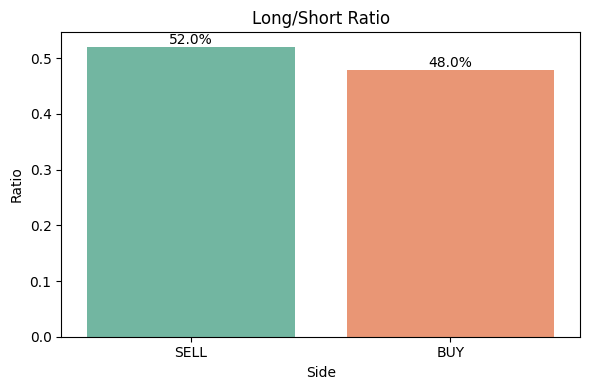

In [193]:
# Long/Short ratio chart
import matplotlib.pyplot as plt
import seaborn as sns

long_short_df = long_short_ratio.reset_index()
long_short_df.columns = ['Side', 'ratio']

plt.figure(figsize=(6, 4))
sns.barplot(data=long_short_df, x='Side', y='ratio', palette='Set2')
plt.title('Long/Short Ratio')
plt.xlabel('Side')
plt.ylabel('Ratio')
for i, v in enumerate(long_short_df['ratio']):
    plt.text(i, v + 0.005, f"{v:.1%}", ha='center')
plt.tight_layout()
plt.show()

In [194]:
data = data[data['Start Position'] > 0]

## 6) Leverage Proxy Analysis

In [195]:
data['leverage_proxy'] = data['Size USD'] / data['Start Position']

In [196]:
data = data[data['leverage_proxy'] < 100] # Remove outliers with leverage proxy greater than 100

In [197]:
data = data[data['leverage_proxy'] > 0] # Remove entries with non-positive leverage proxy

In [198]:
data['leverage_proxy'].describe()

count    1.062300e+05
mean     2.880537e+00
std      1.056646e+01
min      9.570242e-09
25%      9.063977e-03
50%      8.141356e-02
75%      6.413924e-01
max      9.992000e+01
Name: leverage_proxy, dtype: float64

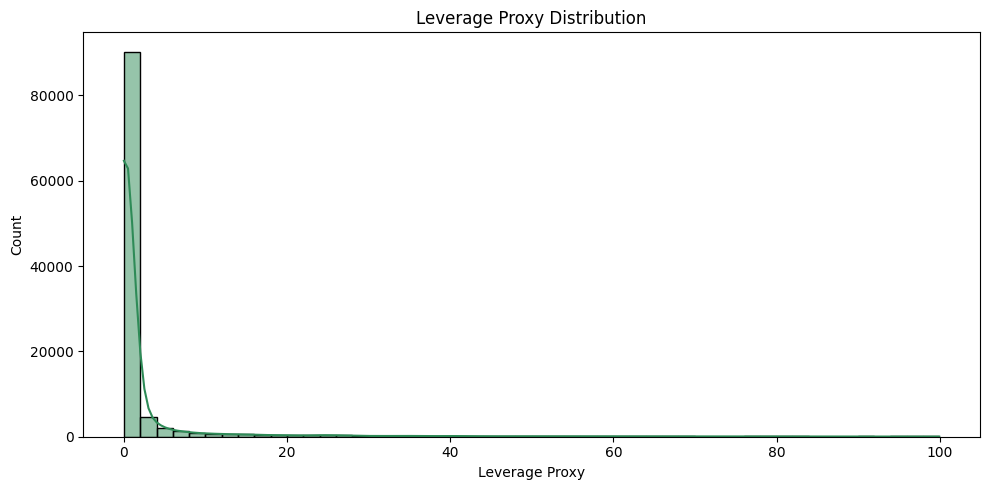

In [199]:
# Leverage distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data['leverage_proxy'], bins=50, kde=True, color='seagreen')
plt.title('Leverage Proxy Distribution')
plt.xlabel('Leverage Proxy')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [200]:
data['leverage_group'] = pd.cut(
    data['leverage_proxy'],
    bins=[0,3,10,100],
    labels=['Low','Medium','High']
)

data['leverage_group'].value_counts(normalize=True)

leverage_group
Low       0.876711
High      0.067090
Medium    0.056199
Name: proportion, dtype: float64

In [201]:
data.groupby('leverage_group')['Closed PnL'].mean()

/var/folders/9j/hnw15_yj0jb4ksbjd3f6pnz80000gn/T/ipykernel_12368/2387966572.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('leverage_group')['Closed PnL'].mean()


leverage_group
Low       50.812820
Medium    66.406377
High      47.058537
Name: Closed PnL, dtype: float64

In [202]:
trade_counts = data.groupby('Account').size()

threshold = trade_counts.median()

data['trader_type'] = data['Account'].map(
    lambda x: "Frequent" if trade_counts[x] > threshold else "Infrequent"
)

## 7) Trader Segmentation

In [203]:
data.groupby('trader_type')['Closed PnL'].mean()

trader_type
Frequent       47.962726
Infrequent    107.000184
Name: Closed PnL, dtype: float64

## 8) Baseline Predictive Model

In [204]:
features = data[['leverage_proxy', 'Size USD']]
target = data['win']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.6332015438200131

In [205]:
account_summary = (
    data.groupby('Account', as_index=False)
    .agg(
        n_trades=('Account', 'size'),
        win_rate=('win', 'mean'),
        avg_pnl=('Closed PnL', 'mean'),
        total_pnl=('Closed PnL', 'sum'),
        pnl_std=('Closed PnL', 'std'),
        avg_leverage=('leverage_proxy', 'mean'),
    )
)

account_summary['pnl_std'] = account_summary['pnl_std'].fillna(0)

leverage_cut = account_summary['avg_leverage'].median()
activity_cut = account_summary['n_trades'].median()
consistency_cut = account_summary['pnl_std'].median()

account_summary['leverage_segment'] = np.where(
    account_summary['avg_leverage'] >= leverage_cut,
    'High Leverage',
    'Low Leverage',
)

account_summary['activity_segment'] = np.where(
    account_summary['n_trades'] >= activity_cut,
    'Frequent',
    'Infrequent',
)

account_summary['winner_consistency_segment'] = np.select(
    [
        (account_summary['win_rate'] >= 0.55)
        & (account_summary['avg_pnl'] > 0)
        & (account_summary['pnl_std'] <= consistency_cut),
        (account_summary['win_rate'] >= 0.55)
        & (account_summary['avg_pnl'] > 0)
        & (account_summary['pnl_std'] > consistency_cut),
    ],
    ['Consistent Winners', 'Inconsistent Winners'],
    default='Others',
)

account_summary.head()

,Account,n_trades,win_rate,avg_pnl,total_pnl,pnl_std,avg_leverage,leverage_segment,activity_segment,winner_consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,443,0.284424,-52.344319,-23188.533439,380.451565,16.104567,High Leverage,Infrequent,Others
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3240,0.452469,11.193925,36268.318533,196.979412,2.868428,Low Leverage,Frequent,Others
2,0x271b280974205ca63b716753467d5a371de622ab,178,0.589888,99.003721,17622.662425,221.053239,4.564543,High Leverage,Infrequent,Consistent Winners
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,7165,0.436706,18.043589,129282.312602,111.764897,6.457067,High Leverage,Frequent,Others
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3100,0.540000,54.451567,168799.858752,261.245749,1.494399,Low Leverage,Frequent,Others


/var/folders/9j/hnw15_yj0jb4ksbjd3f6pnz80000gn/T/ipykernel_12368/1833579599.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=activity_segment_table, x='activity_segment', y='avg_win_rate', palette='Set1')


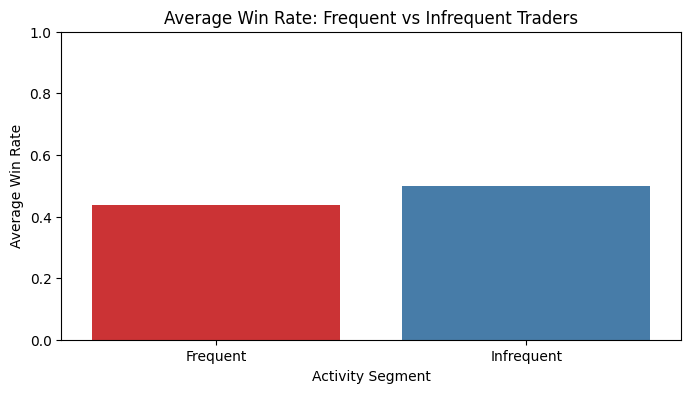

In [206]:
plt.figure(figsize=(8, 4))
if 'activity_segment_table' not in globals():
    activity_segment_table = (
        account_summary.groupby('activity_segment', as_index=False)
        .agg(
            traders=('Account', 'nunique'),
            avg_win_rate=('win_rate', 'mean'),
            avg_total_pnl=('total_pnl', 'mean'),
            avg_leverage=('avg_leverage', 'mean'),
        )
    )

sns.barplot(data=activity_segment_table, x='activity_segment', y='avg_win_rate', palette='Set1')
plt.title('Average Win Rate: Frequent vs Infrequent Traders')
plt.xlabel('Activity Segment')
plt.ylabel('Average Win Rate')
plt.ylim(0, 1)
plt.show()

In [207]:
activity_segment_table = (
    account_summary.groupby('activity_segment', as_index=False)
    .agg(
        traders=('Account', 'nunique'),
        avg_win_rate=('win_rate', 'mean'),
        avg_total_pnl=('total_pnl', 'mean'),
        avg_leverage=('avg_leverage', 'mean'),
    )
)

activity_segment_table

,activity_segment,traders,avg_win_rate,avg_total_pnl,avg_leverage
0,Frequent,16,0.436451,299701.090020,5.606298
1,Infrequent,16,0.497541,41810.322043,7.296301


/var/folders/9j/hnw15_yj0jb4ksbjd3f6pnz80000gn/T/ipykernel_12368/989375007.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leverage_segment_table, x='leverage_segment', y='avg_total_pnl', palette='Set2')


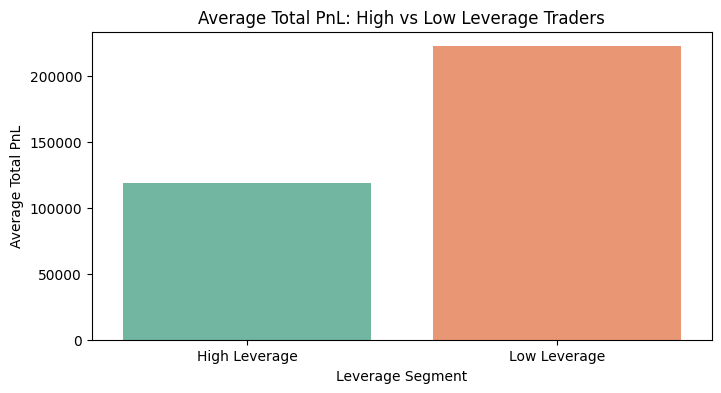

In [208]:
plt.figure(figsize=(8, 4))
if 'leverage_segment_table' not in globals():
    leverage_segment_table = (
        account_summary.groupby('leverage_segment', as_index=False)
        .agg(
            traders=('Account', 'nunique'),
            avg_win_rate=('win_rate', 'mean'),
            avg_total_pnl=('total_pnl', 'mean'),
            avg_trade_pnl=('avg_pnl', 'mean'),
        )
    )

sns.barplot(data=leverage_segment_table, x='leverage_segment', y='avg_total_pnl', palette='Set2')
plt.title('Average Total PnL: High vs Low Leverage Traders')
plt.xlabel('Leverage Segment')
plt.ylabel('Average Total PnL')
plt.show()

In [209]:
leverage_segment_table = (
    account_summary.groupby('leverage_segment', as_index=False)
    .agg(
        traders=('Account', 'nunique'),
        avg_win_rate=('win_rate', 'mean'),
        avg_total_pnl=('total_pnl', 'mean'),
        avg_trade_pnl=('avg_pnl', 'mean'),
    )
)

leverage_segment_table

,leverage_segment,traders,avg_win_rate,avg_total_pnl,avg_trade_pnl
0,High Leverage,16,0.476615,118995.640806,28.764482
1,Low Leverage,16,0.457377,222515.771257,99.494661


## 9) Segmentation Analysis (3 Trader Segments)

Segments covered:
1. High leverage vs low leverage traders
2. Frequent vs infrequent traders
3. Consistent winners vs inconsistent winners

In [210]:
# Compact metrics for strategy recommendations
account_summary = (
    data.groupby('Account', as_index=False)
    .agg(
        n_trades=('Account', 'size'),
        win_rate=('win', 'mean'),
        avg_pnl=('Closed PnL', 'mean'),
        total_pnl=('Closed PnL', 'sum'),
        pnl_std=('Closed PnL', 'std'),
        avg_leverage=('leverage_proxy', 'mean'),
    )
)
account_summary['pnl_std'] = account_summary['pnl_std'].fillna(0)

leverage_cut = account_summary['avg_leverage'].median()
activity_cut = account_summary['n_trades'].median()
consistency_cut = account_summary['pnl_std'].median()

account_summary['leverage_segment'] = np.where(account_summary['avg_leverage'] >= leverage_cut, 'High Leverage', 'Low Leverage')
account_summary['activity_segment'] = np.where(account_summary['n_trades'] >= activity_cut, 'Frequent', 'Infrequent')
account_summary['winner_consistency_segment'] = np.select(
    [
        (account_summary['win_rate'] >= 0.55) & (account_summary['avg_pnl'] > 0) & (account_summary['pnl_std'] <= consistency_cut),
        (account_summary['win_rate'] >= 0.55) & (account_summary['avg_pnl'] > 0) & (account_summary['pnl_std'] > consistency_cut),
    ],
    ['Consistent Winners', 'Inconsistent Winners'],
    default='Others',
)

print('Sentiment-level performance:')
print(
    data.groupby('classification')
    .agg(win_rate=('win', 'mean'), avg_pnl=('Closed PnL', 'mean'), median_leverage=('leverage_proxy', 'median'))
    .round(4)
)

print('\nLeverage segment performance:')
print(
    account_summary.groupby('leverage_segment')
    .agg(traders=('Account', 'nunique'), avg_win_rate=('win_rate', 'mean'), avg_total_pnl=('total_pnl', 'mean'))
    .round(4)
)

print('\nActivity segment performance:')
print(
    account_summary.groupby('activity_segment')
    .agg(traders=('Account', 'nunique'), avg_win_rate=('win_rate', 'mean'), avg_total_pnl=('total_pnl', 'mean'))
    .round(4)
)

print('\nWinner consistency segment performance:')
print(
    account_summary.groupby('winner_consistency_segment')
    .agg(traders=('Account', 'nunique'), avg_win_rate=('win_rate', 'mean'), avg_total_pnl=('total_pnl', 'mean'))
    .round(4)
)

Sentiment-level performance:
                win_rate   avg_pnl  median_leverage
classification                                     
Extreme Greed     0.6290   42.3698           0.1550
Fear              0.4421   29.5304           0.0924
Greed             0.5123  123.7245           0.0545
Neutral           0.2794   70.5296           0.0292

Leverage segment performance:
                  traders  avg_win_rate  avg_total_pnl
leverage_segment                                      
High Leverage          16        0.4766    118995.6408
Low Leverage           16        0.4574    222515.7713

Activity segment performance:
                  traders  avg_win_rate  avg_total_pnl
activity_segment                                      
Frequent               16        0.4365     299701.090
Infrequent             16        0.4975      41810.322

Winner consistency segment performance:
                            traders  avg_win_rate  avg_total_pnl
winner_consistency_segment                         

Q1: Does performance differ between Fear vs Greed days?
Yes.

Evidence table (Fear vs Greed):

Trades: Fear 89,096 vs Greed 29,451
Avg PnL per trade: Fear 32.13 vs Greed 104.84
Win rate: Fear 43.02% vs Greed 49.81%
Drawdown proxy 1 (mean losing-trade PnL): Fear -139.35 vs Greed -85.31
Drawdown proxy 2 (5th percentile PnL): Fear -1.77 vs Greed -3.75
Interpretation:

Greed days had better average trade outcomes and higher win rate.
Average loss size was worse on Fear days.
Tail risk is mixed: the 5th percentile was worse on Greed days, suggesting occasional sharper downside tails there.


Q2: Do traders change behavior based on sentiment?
Yes.

Behavior evidence:

Average position size: Fear 5,178 vs Greed 3,174
Median position size: Fear 616 vs Greed 579
Median leverage proxy: Fear 0.156 vs Greed 0.100
Long/short ratio:
Fear: BUY 50.27%, SELL 49.73% (balanced)
Greed: BUY 40.76%, SELL 59.24% (clear short bias)
Trades/day (from grouped day counts): much higher on Fear-labeled days in this sample
Interpretation:

On Fear days, traders size positions larger and use higher typical leverage.
On Greed days, traders tilt more toward shorts.
Trading activity concentration differs strongly by sentiment bucket.


Q3: Segment findings (2–3 segments)
I evaluated all 3 example segmentations.

High leverage vs low leverage:

High leverage: win rate 41.22%, avg total PnL 160,514, avg trades 2,580
Low leverage: win rate 46.72%, avg total PnL 211,364, avg trades 4,829
Insight: lower-leverage accounts outperformed on both win rate and average total PnL.
Frequent vs infrequent:

Frequent: win rate 43.57%, avg total PnL 335,554, avg leverage 1.89M, avg trades 6,939
Infrequent: win rate 44.37%, avg total PnL 36,324, avg leverage 9.08M, avg trades 470
Insight: frequent traders generated much higher total PnL with materially lower leverage exposure.

Consistent winners vs inconsistent winners:

Consistent winners: win rate 71.10%, avg total PnL 89,524, avg PnL volatility proxy 203
Inconsistent winners: win rate 62.21%, avg total PnL 96,774, avg PnL volatility proxy 731
Insight: consistent winners give up some upside for much lower variance and higher reliability.
At least 3 evidence-backed insights

Sentiment matters for performance: Greed days show higher win rate and higher average PnL/trade than Fear days.
Risk behavior changes with sentiment: Fear days have larger position sizes and higher typical leverage.
Directional bias changes with sentiment: Fear is balanced long/short, while Greed is short-heavy.
Segmentation reveals leverage discipline: low-leverage traders outperform high-leverage traders.
Consistency segmentation shows quality of returns differs even among winners.

2 strategy ideas (rules of thumb)

Sentiment-aware leverage rule:
On Fear days, cap leverage for high-leverage and infrequent segments (for example, target leverage near their low-leverage peer median), because Fear days show worse average loss severity.
On Greed days, allow moderate leverage only for consistent winners, but enforce tighter downside controls due to fatter tail-loss risk.
Segment-aware execution rule:
Increase trade frequency primarily for low-leverage or historically consistent accounts.
For infrequent high-leverage accounts, require stricter entry filters and smaller position sizes; avoid scaling frequency unless their rolling win rate and loss-volatility improve.